# Stationarity Diagnostics — Daily Aggregate Sales


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller, kpss, acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 100

# Project root
root = Path.cwd()
while root.name and not (root / 'pyproject.toml').exists():
    root = root.parent
if str(root) not in sys.path:
    sys.path.append(str(root))

from configs.config import RAW_DIR

## 1. Load & aggregate

National daily aggregate — acceptable for diagnosing overall stationarity properties, but not representative of per-(store, family) behavior.

In [2]:
train = pd.read_csv(RAW_DIR / 'train.csv', parse_dates=['date'])

# Aggregate to daily total sales
daily_sales = train.groupby('date')['sales'].sum()

# Reindex to complete date range (fill 4 missing Christmas dates with 0, NOT ffill)
full_range = pd.date_range(start=daily_sales.index.min(),
                           end=daily_sales.index.max(), freq='D')
daily_sales = daily_sales.reindex(full_range, fill_value=0.0)
daily_sales.index.name = 'date'

missing_dates = full_range.difference(train['date'].unique())
print(f"Date range: {full_range[0].date()} to {full_range[-1].date()} ({len(full_range)} days)")
print(f"Missing dates filled with 0: {[d.date() for d in missing_dates]}")

# Apply log1p (locked target transform)
y = np.log1p(daily_sales)
y.name = 'log1p_sales'
print(f"Series length after reindex: {len(y)}")

Date range: 2013-01-01 to 2017-08-15 (1688 days)
Missing dates filled with 0: [datetime.date(2013, 12, 25), datetime.date(2014, 12, 25), datetime.date(2015, 12, 25), datetime.date(2016, 12, 25)]
Series length after reindex: 1688


## 2. ADF + KPSS tests


In [3]:
def run_stationarity_tests(series, label):
    """Run ADF and KPSS, return dict with test stats and verdicts."""
    adf_stat, adf_pval, _, _, adf_crit, _ = adfuller(series.dropna(), autolag='AIC')
    kpss_stat, kpss_pval, _, kpss_crit = kpss(series.dropna(), regression='c', nlags='auto')
    return {
        'level': label,
        'ADF stat': f'{adf_stat:.4f}',
        'ADF p': f'{adf_pval:.4f}',
        'ADF reject H0': adf_pval < 0.05,
        'KPSS stat': f'{kpss_stat:.4f}',
        'KPSS p': f'{kpss_pval:.3f}',
        'KPSS reject H0': kpss_pval < 0.05,
    }

def classify(adf_reject, kpss_reject):
    """Standard 4-quadrant ADF+KPSS classification."""
    if adf_reject and not kpss_reject:
        return 'Stationary'
    elif not adf_reject and kpss_reject:
        return 'Non-stationary'
    elif adf_reject and kpss_reject:
        return 'Trend-stationary'
    else:
        return 'Difference-stationary'

# Compute differenced series
y_d1 = y.diff().dropna()
y_d2 = y.diff().diff().dropna()

# Run tests
results = [
    run_stationarity_tests(y, 'd=0 (log1p)'),
    run_stationarity_tests(y_d1, 'd=1'),
]

# Only test d=2 if d=1 doesn't achieve stationarity by both tests
r1 = results[1]
d1_stationary = r1['ADF reject H0'] and not r1['KPSS reject H0']
if not d1_stationary:
    results.append(run_stationarity_tests(y_d2, 'd=2'))
    print("d=1 did not achieve stationarity by both tests; added d=2.")
else:
    print("d=1 achieves stationarity by both tests; d=2 not needed.")

d=1 achieves stationarity by both tests; d=2 not needed.


C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_26336\4111860788.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_pval, _, kpss_crit = kpss(series.dropna(), regression='c', nlags='auto')
C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_26336\4111860788.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pval, _, kpss_crit = kpss(series.dropna(), regression='c', nlags='auto')


### Decision table (4-quadrant rule)


In [4]:
table_rows = []
for r in results:
    verdict = classify(r['ADF reject H0'], r['KPSS reject H0'])
    table_rows.append({
        'Level': r['level'],
        'ADF stat': r['ADF stat'],
        'ADF p': r['ADF p'],
        'ADF reject': r['ADF reject H0'],
        'KPSS stat': r['KPSS stat'],
        'KPSS p': r['KPSS p'],
        'KPSS reject': r['KPSS reject H0'],
        'Verdict': verdict,
    })

df_table = pd.DataFrame(table_rows)
print(df_table.to_string(index=False))

      Level ADF stat  ADF p  ADF reject KPSS stat KPSS p  KPSS reject          Verdict
d=0 (log1p)  -4.0746 0.0011        True    6.8754  0.010         True Trend-stationary
        d=1 -15.2452 0.0000        True    0.2506  0.100        False       Stationary


## 3. ACF / PACF plots


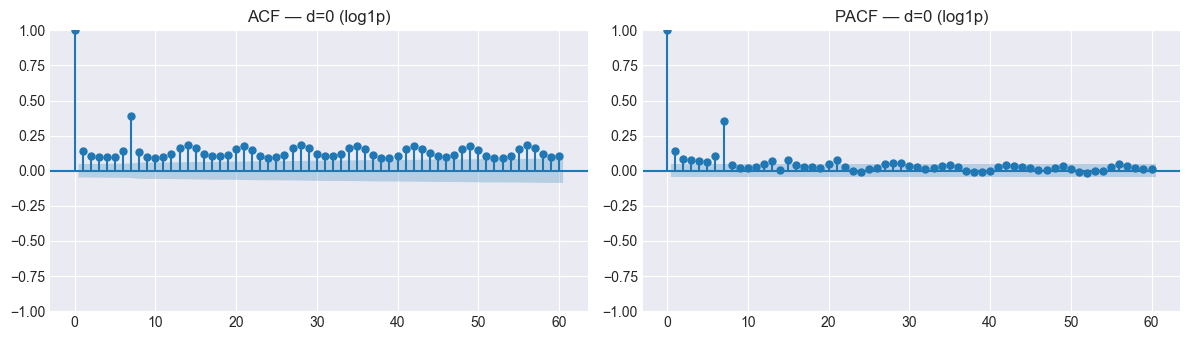

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_acf(y, lags=60, ax=axes[0], title='ACF — d=0 (log1p)')
plot_pacf(y, lags=60, ax=axes[1], title='PACF — d=0 (log1p)', method='ywm')
plt.tight_layout()
plt.show()

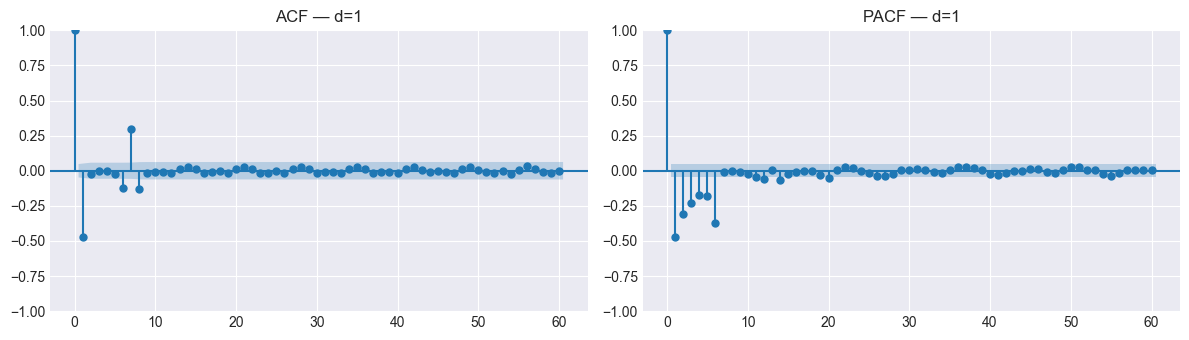

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_acf(y_d1, lags=60, ax=axes[0], title='ACF — d=1')
plot_pacf(y_d1, lags=60, ax=axes[1], title='PACF — d=1', method='ywm')
plt.tight_layout()
plt.show()

In [7]:
if not d1_stationary:
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
    plot_acf(y_d2, lags=60, ax=axes[0], title='ACF — d=2')
    plot_pacf(y_d2, lags=60, ax=axes[1], title='PACF — d=2', method='ywm')
    plt.tight_layout()
    plt.show()
else:
    print('d=2 plots skipped (d=1 already stationary).')

d=2 plots skipped (d=1 already stationary).


## 4. Summary


In [8]:
# Determine recommended d
recommended_d = None
for r in results:
    verdict = classify(r['ADF reject H0'], r['KPSS reject H0'])
    if verdict == 'Stationary':
        d_val = int(r['level'].split('=')[1][0])
        recommended_d = d_val
        break

if recommended_d is None:
    for r in results:
        if r['ADF reject H0']:
            d_val = int(r['level'].split('=')[1][0])
            recommended_d = d_val
            break

print(f"Recommended d = {recommended_d}")
print()

# Identify dominant ACF peaks at d=1 to confirm seasonal period
acf_vals = acf(y_d1, nlags=30)
# Find lags with |ACF| > 2/sqrt(n) (approximate 95% CI)
ci = 2 / np.sqrt(len(y_d1))
significant_lags = [i for i in range(1, 31) if abs(acf_vals[i]) > ci]
print(f"Significant ACF lags at d=1 (|ACF| > {ci:.4f}): {significant_lags}")

# Check if lag 7 is the dominant seasonal peak
lag7_acf = acf_vals[7]
print(f"ACF at lag 7: {lag7_acf:.4f} — {'confirms' if lag7_acf > ci else 'does not confirm'} weekly seasonality")
print()
print("FE implications:")
print(f"  - First differencing (d={recommended_d}) removes trend; a differenced feature may add signal.")
print("  - Dominant seasonal period s=7 (weekly) should be used for seasonal features/decomposition.")
print("  - SARIMA diagnostic notebook will validate at per-series level.")

Recommended d = 1

Significant ACF lags at d=1 (|ACF| > 0.0487): [1, 6, 7, 8]
ACF at lag 7: 0.2973 — confirms weekly seasonality

FE implications:
  - First differencing (d=1) removes trend; a differenced feature may add signal.
  - Dominant seasonal period s=7 (weekly) should be used for seasonal features/decomposition.
  - SARIMA diagnostic notebook will validate at per-series level.
